<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_ResNet_Pretrained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_ResNet_Pretrained

ResNet50 fine-tuned from ImageNet weights on VWW using three-phase progressive unfreezing.

**Three-phase protocol (mirrors VGG_Pretrained):**
- Phase 1 (epochs 1–9): entire backbone frozen, train head only at `lr=3e-4`
- Phase 2 (epochs 10–19): unfreeze `layer3 + layer4` at `lr=1e-4`
- Phase 3 (epochs 20–30): unfreeze all backbone layers at `lr=3e-5`

**Note:** ResNet50 has ~25M parameters vs VGG16-BN's ~138M.  
Both are over-parameterized for this 7k-image binary task, but ResNet50 is  
significantly leaner and generalizes better on small datasets.  
Compare `vgg_pretrained_seed_85` vs `resnet_pretrained_seed_85` to see which makes the stronger KD teacher.

**Prerequisites:** Run `Model_MobileNetV2.ipynb` and `Model_VGG_Pretrained.ipynb` first.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os
import numpy as np
import torch

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import ResNet_Pretrained, count_params, model_size_mb
from utils.train   import setup_device, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [4]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [5]:
# ── Parameter count ─────────────────────────────────────────────────
model_tmp = ResNet_Pretrained().to(device)
total, trainable = count_params(model_tmp)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  (head only at start)")
print(f"Model size      : {model_size_mb(model_tmp):.1f} MB")
del model_tmp

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Total params    : 24,623,042
Trainable params: 1,115,010  (head only at start)
Model size      : 98.8 MB


In [6]:
# ── Train across 5 seeds ─────────────────────────────────────────────
results, best = train_multi_seed(
    model_fn     = ResNet_Pretrained,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "resnet_pretrained",
    pretrained   = True,
    # Three-phase hyperparameters
    epochs       = 30,
    lr_phase1    = 3e-4,
    lr_phase2    = 1e-4,
    lr_phase3    = 3e-5,
    phase2_epoch = 10,
    phase3_epoch = 20,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)


Seed 41
[P1] Epoch   1/30 | LR 0.000291 | Train 68.64% | Val 76.00% ✅
[P1] Epoch   2/30 | LR 0.000265 | Train 74.90% | Val 71.20%
[P1] Epoch   3/30 | LR 0.000225 | Train 75.54% | Val 79.00% ✅
[P1] Epoch   4/30 | LR 0.000176 | Train 76.00% | Val 79.67% ✅
[P1] Epoch   5/30 | LR 0.000124 | Train 77.31% | Val 78.53%
[P1] Epoch   6/30 | LR 0.000075 | Train 76.57% | Val 78.40%
[P1] Epoch   7/30 | LR 0.000035 | Train 78.01% | Val 79.80% ✅
[P1] Epoch   8/30 | LR 0.000009 | Train 77.61% | Val 80.13% ✅
[P1] Epoch   9/30 | LR 0.000000 | Train 78.40% | Val 79.60%

── Phase 2: partial unfreeze (epoch 10) ──
🔥 ResNet50: unfroze layer3 + layer4
[P2] Epoch  10/30 | LR 0.000098 | Train 82.07% | Val 84.67% ✅
[P2] Epoch  11/30 | LR 0.000090 | Train 87.97% | Val 85.93% ✅
[P2] Epoch  12/30 | LR 0.000079 | Train 89.81% | Val 85.60%
[P2] Epoch  13/30 | LR 0.000065 | Train 91.74% | Val 87.47% ✅
[P2] Epoch  14/30 | LR 0.000050 | Train 93.93% | Val 85.07%
[P2] Epoch  15/30 | LR 0.000035 | Train 95.13% | Val 86

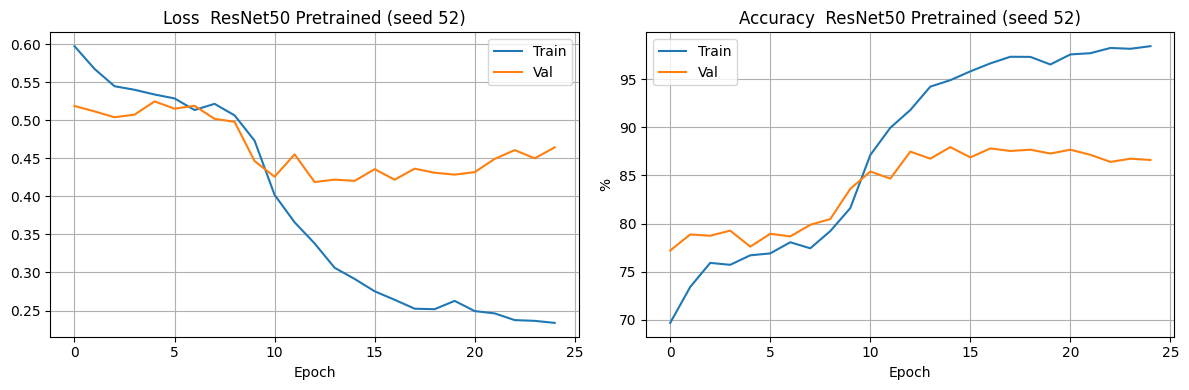

Best: 87.93% @ epoch 15  (7.0 min)

ResNet50 Pretrained  |  Mean: 87.45% ± 0.35%  |  Best: 87.93% (seed 52)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/resnet_pretrained_seed_52.pth


In [7]:
plot_history(best, title=f"ResNet50 Pretrained (seed {best['seed']})")

accs = [r['best_acc'] for r in results]
print(f"\nResNet50 Pretrained  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")

---
## ResNet50 vs VGG16-BN Pretrained
Run `Model_VGG_Pretrained.ipynb` first, then compare teacher candidates below.

In [8]:
# ── Teacher candidate comparison ─────────────────────────────────────
from utils.models import VGG_Pretrained

VGG_CKPT = f"{SAVE_DIR}/vgg_pretrained_seed_85.pth"   # verify: check Model_VGG_Pretrained output for best seed

resnet_model = ResNet_Pretrained().to(device)
resnet_model.load_state_dict(torch.load(best['save_path'], map_location=device))
resnet_acc = evaluate(resnet_model, val_loader, device)

if os.path.exists(VGG_CKPT):
    vgg_model = VGG_Pretrained().to(device)
    vgg_model.load_state_dict(torch.load(VGG_CKPT, map_location=device))
    vgg_acc = evaluate(vgg_model, val_loader, device)
else:
    vgg_acc = None
    print("⚠️  VGG_Pretrained checkpoint not found — run Model_VGG_Pretrained first")

resnet_total, _ = count_params(resnet_model)

print("=" * 52)
print(f"{'Model':<28} {'Val Acc':>9} {'Params':>12}")
print("-" * 52)
print(f"{'ResNet50 Pretrained':<28} {resnet_acc*100:>8.2f}% {resnet_total:>12,}")
if vgg_acc is not None:
    vgg_total, _ = count_params(vgg_model)
    print(f"{'VGG16-BN Pretrained':<28} {vgg_acc*100:>8.2f}% {vgg_total:>12,}")
    print("-" * 52)
    print(f"{'Gap (ResNet - VGG)':<28} {(resnet_acc - vgg_acc)*100:>+8.2f}%")
print("=" * 52)

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:06<00:00, 83.5MB/s]


Model                          Val Acc       Params
----------------------------------------------------
ResNet50 Pretrained             87.93%   24,623,042
VGG16-BN Pretrained             89.07%   27,634,626
----------------------------------------------------
Gap (ResNet - VGG)              -1.13%
